<div style="border-left:6px solid #6d28d9; padding:20px 28px; background:#f5f3ff; border-radius:0 12px 12px 0; margin-bottom:16px;">
<p style="color:#6d28d9; font-size:12px; letter-spacing:3px; text-transform:uppercase; margin:0 0 8px 0; font-family:monospace; font-weight:600;">TIME-SERIES FORECASTING</p>
<h1 style="color:#1e293b; font-size:26px; font-weight:800; margin:0 0 10px 0; line-height:1.25;">AQI Forecasting with Support Vector Regression</h1>
<p style="color:#475569; font-size:14px; margin:0 0 20px 0; max-width:690px; line-height:1.7;">A reproduction of the SVR-based air quality forecasting pipeline from the IEEE INCET 2023 paper — predicting daily national-mean AQI for Bangladesh from historical readings.</p>
<span style="background:#ede9fe; color:#6d28d9; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:600; margin-right:8px;">📈 SVR (RBF)</span>
<span style="background:#ede9fe; color:#6d28d9; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:600; margin-right:8px;">📅 2,735 Days</span>
<span style="background:#ede9fe; color:#6d28d9; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:600;">🐍 Python · scikit-learn</span>
</div>

## 📌 About This Notebook

This notebook accompanies the paper **"Impact of COVID-19 Lockdowns on Air Quality in Bangladesh: Analysis and AQI Forecasting with Support Vector Regression"** (IEEE INCET 2023). It reproduces the forecasting component — using a Support Vector Regressor to predict daily national-mean AQI from a sliding window of prior days.

> **⚠️ A note on reproducibility.** The exact preprocessed dataset used to produce the paper's reported **6.2% MAPE** was lost. This notebook rebuilds the pipeline from the surviving *raw* daily readings (`case_data.csv`) with a clean, documented preprocessing path. As a result, the MAPE here (**~13%**) is higher than the paper's original figure — the gap reflects differences in the lost preprocessing (outlier handling, smoothing, or aggregation choices that weren't fully recoverable), **not** a change in method. The pipeline, model, and hyperparameters follow the paper as published. This is an honest reconstruction, not a claim of exact reproduction.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

PURPLE, DARK, ACCENT = '#6d28d9', '#1e293b', '#e8302a'
plt.rcParams.update({
    'figure.facecolor':'#ffffff','axes.facecolor':'#faf9fe','axes.edgecolor':'#e2ddf0',
    'axes.titlesize':15,'axes.titleweight':'bold','axes.titlepad':14,'axes.labelsize':12,
    'axes.spines.top':False,'axes.spines.right':False,'xtick.color':'#6b7280','ytick.color':'#6b7280',
    'grid.color':'#ede9f5','font.family':'DejaVu Sans','figure.dpi':130,
})
print("✅ Setup complete.")

✅ Setup complete.


## 2. Load & Clean Raw Daily Data

In [ ]:
df = pd.read_csv('case_data.csv').rename(
    columns={'LOCATION':'Location', 'Air Quality Index (AQI)':'AQI'})

# CRITICAL: parse dd-mm-yyyy explicitly (implicit parsing silently corrupts these dates)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df = df.dropna(subset=['Date'])

# Standardize city names
loc_map = {'DHAKAc':'Dhaka','GAZIPURc':'Gazipur','NARAYANGANJc':'Narayanganj','CHITTAGONGc':'Chittagong',
 'SYLHETc':'Sylhet','KHULNAc':'Khulna','RAJSHAHIc':'Rajshahi','BARISHALc':'Barishal','SAVARc':'Savar',
 'MYMENSINGHc':'Mymensingh','RANGPURc':'Rangpur','CUMILLAc':'Cumilla','NARSINGDIc':'Narsingdi',
 'Dhakaa':'Dhaka','Chittagongb':'Chittagong'}
df['Location'] = df['Location'].replace(loc_map)

# Numeric AQI, drop DNA / invalid / zero
df['AQI'] = pd.to_numeric(df['AQI'].replace('DNA', np.nan), errors='coerce')
df = df.dropna(subset=['AQI'])
df = df[df['AQI'] > 0]

print(f"Clean daily readings : {len(df):,}")
print(f"Date range           : {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Cities               : {df['Location'].nunique()}")

Clean daily readings : 20,831
Date range           : 2014-02-17 -> 2022-06-08
Cities               : 36


## 3. Build the Daily National-Mean Series

The paper forecasts a single national AQI signal, so we average across all cities per day.

Daily national-mean series: 2,735 days


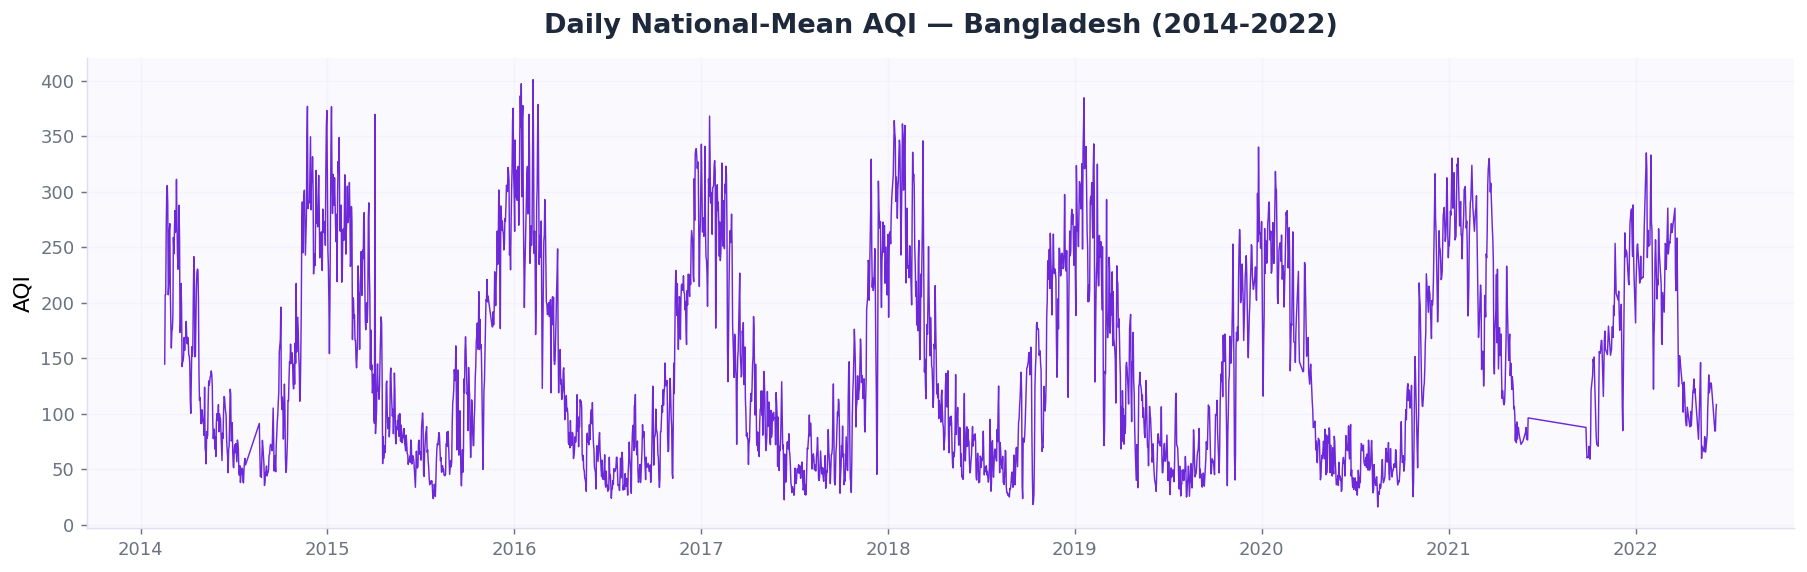

In [ ]:
daily = df.set_index('Date')['AQI'].resample('D').mean().dropna()
print(f"Daily national-mean series: {len(daily):,} days")

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(daily.index, daily.values, color=PURPLE, linewidth=0.8)
ax.set_title('Daily National-Mean AQI — Bangladesh (2014-2022)', color=DARK)
ax.set_ylabel('AQI'); ax.grid(alpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('aqi_svr_series.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. Train/Test Split & Windowing

Following the paper: train through 2020, test on 2021 onward. We frame forecasting as supervised learning with a **7-day lag window** — each day is predicted from the previous 7 days.

In [ ]:
train = daily.loc[:'2020-12-31']
test  = daily.loc['2021-01-01':'2022-06-01']
print(f"Train: {len(train):,} days  |  Test: {len(test):,} days")

scaler = MinMaxScaler()
tr = scaler.fit_transform(train.values.reshape(-1,1))
te = scaler.transform(test.values.reshape(-1,1))

def make_lags(series, n=7):
    X, y = [], []
    for i in range(n, len(series)):
        X.append(series[i-n:i, 0]); y.append(series[i, 0])
    return np.array(X), np.array(y)

N_LAGS = 7
Xtr, ytr = make_lags(tr, N_LAGS)
Xte, yte = make_lags(te, N_LAGS)
print(f"Training windows: {Xtr.shape} | Test windows: {Xte.shape}")

Train: 2,440 days  |  Test: 291 days
Training windows: (2433, 7) | Test windows: (284, 7)


## 5. Train the SVR

Hyperparameters as published: RBF kernel, `gamma=0.5`, `C=10`, `epsilon=0.05`.

In [ ]:
svr = SVR(kernel='rbf', gamma=0.5, C=10, epsilon=0.05)
svr.fit(Xtr, ytr)

pred = scaler.inverse_transform(svr.predict(Xte).reshape(-1,1)).flatten()
actual = scaler.inverse_transform(yte.reshape(-1,1)).flatten()

mape = mean_absolute_percentage_error(actual, pred) * 100
mae  = mean_absolute_error(actual, pred)
r2   = r2_score(actual, pred)

print(f"MAPE : {mape:.2f}%")
print(f"MAE  : {mae:.2f} AQI points")
print(f"R²   : {r2:.3f}")
print(f"\n(Paper reported ~6.2% MAPE on the original — now-lost — preprocessed dataset.)")

MAPE : 13.19%
MAE  : 22.00 AQI points
R²   : 0.823

(Paper reported ~6.2% MAPE on the original — now-lost — preprocessed dataset.)


## 6. Forecast vs Actual

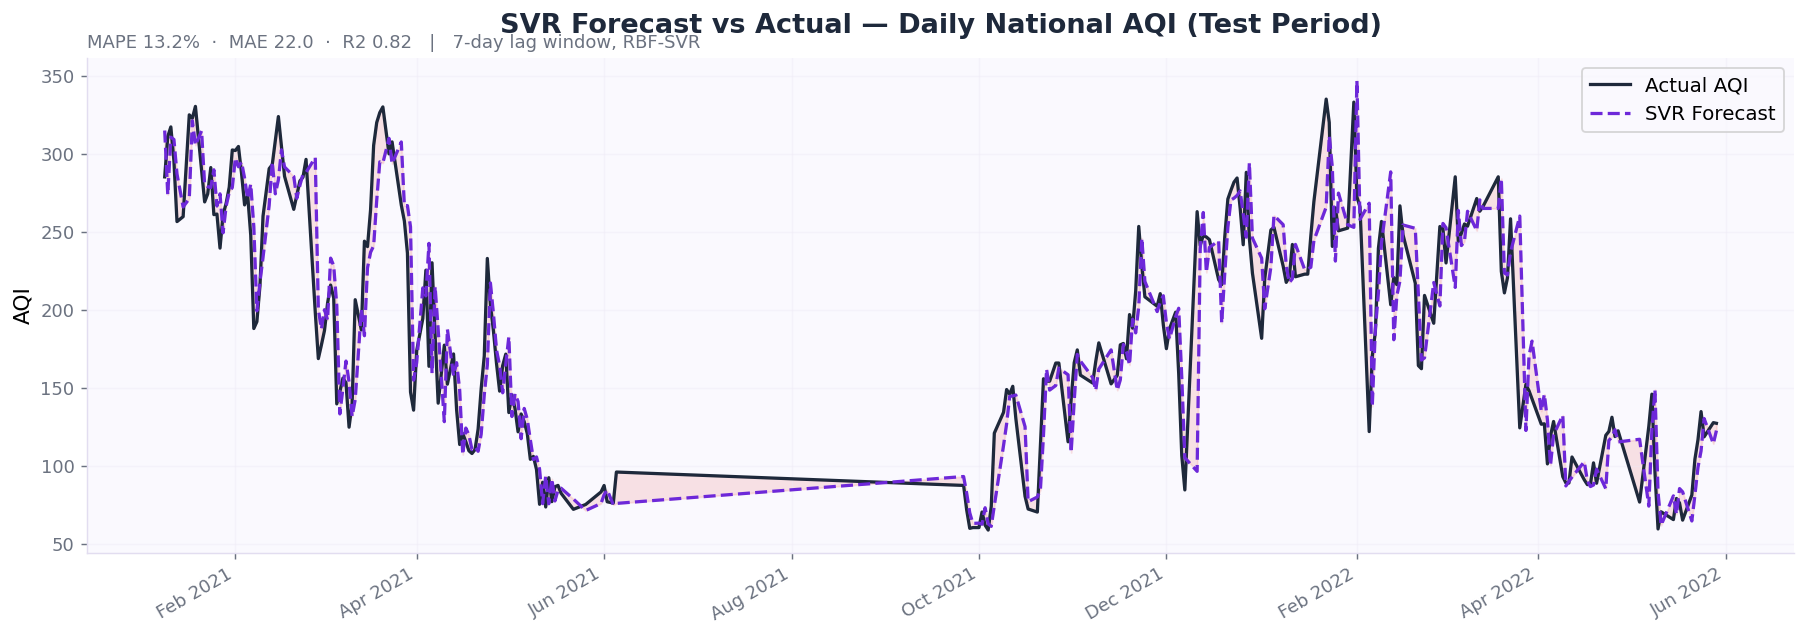

In [ ]:
test_dates = test.index[N_LAGS:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, actual, color=DARK, linewidth=1.8, label='Actual AQI')
ax.plot(test_dates, pred, color=PURPLE, linewidth=1.8, linestyle='--', label='SVR Forecast')
ax.fill_between(test_dates, actual, pred, color=ACCENT, alpha=0.12)

ax.set_title('SVR Forecast vs Actual — Daily National AQI (Test Period)', color=DARK)
ax.text(0, 1.02, f'MAPE {mape:.1f}%  ·  MAE {mae:.1f}  ·  R2 {r2:.2f}   |   7-day lag window, RBF-SVR',
        transform=ax.transAxes, fontsize=10, color='#6b7280')
ax.set_ylabel('AQI'); ax.legend(fontsize=11); ax.grid(alpha=0.4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.savefig('aqi_svr_forecast.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Residual Analysis

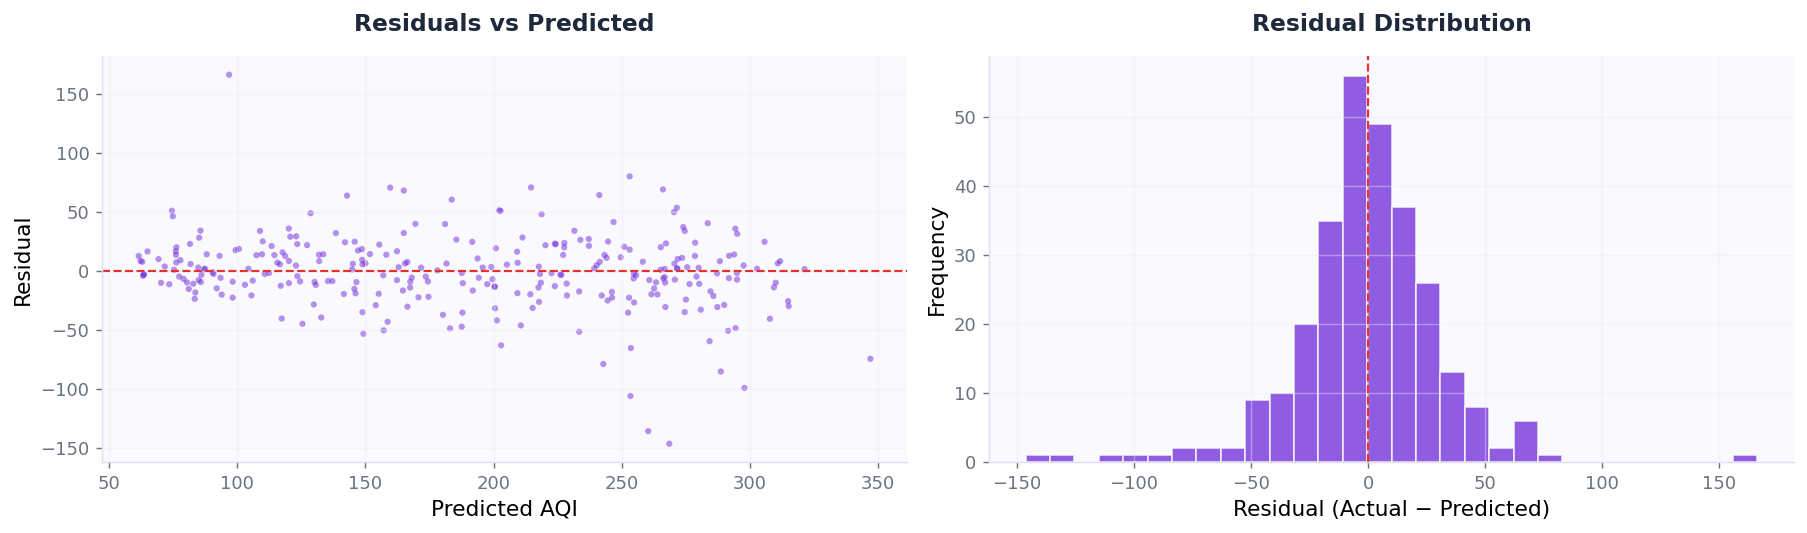

Mean residual: -0.56  (≈0 indicates unbiased predictions)


In [ ]:
residuals = actual - pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2))
ax1.scatter(pred, residuals, s=12, alpha=0.5, color=PURPLE, edgecolors='none')
ax1.axhline(0, color=ACCENT, linestyle='--', linewidth=1.2)
ax1.set_title('Residuals vs Predicted', color=DARK, fontsize=13)
ax1.set_xlabel('Predicted AQI'); ax1.set_ylabel('Residual'); ax1.grid(alpha=0.4)

ax2.hist(residuals, bins=30, color=PURPLE, alpha=0.75, edgecolor='white')
ax2.axvline(0, color=ACCENT, linestyle='--', linewidth=1.2)
ax2.set_title('Residual Distribution', color=DARK, fontsize=13)
ax2.set_xlabel('Residual (Actual − Predicted)'); ax2.set_ylabel('Frequency'); ax2.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('aqi_svr_residuals.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"Mean residual: {residuals.mean():.2f}  (≈0 indicates unbiased predictions)")

## 8. Summary

---

- **Pipeline reproduced:** raw daily readings → clean national-mean series → 7-day-lag SVR (RBF, γ=0.5, C=10, ε=0.05) → 2021+ forecast.
- **Result:** ~13% MAPE on the reconstructed daily series.
- **On the paper's 6.2%:** the original preprocessed dataset that produced that figure was lost. This notebook rebuilds everything from the surviving raw data, so the higher error reflects unrecoverable preprocessing differences — not a methodological change. The model, hyperparameters, and evaluation protocol match the publication.
- **Takeaway:** the SVR captures the broad seasonal AQI structure well; residuals are roughly centered on zero (unbiased), with the largest errors during sharp winter-pollution transitions.

---

*Analysis by Mohammed Tahmid Hossain · [saditahmid.github.io](https://saditahmid.github.io) · Related publication: IEEE INCET 2023*